In [ ]:
# Smart Traffic Sign Recognition System
# Scenario
# A city is building a Smart Traffic Monitoring System to improve road safety.

# Every intersection in the city will have cameras that detect traffic signs automatically.

# The system must recognize different road signs such as:

# Stop sign

# Speed limit sign

# Pedestrian crossing sign

# The system will be used in autonomous vehicles and traffic monitoring cameras.

# However, the engineers discovered two challenges:

# 1️ First, the system must understand basic classification logic (learning from features).
# 2️ Second, it must classify images of traffic signs captured by cameras.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# 2. Load Dataset
df = pd.read_csv("DatasetCapstoneProject4.csv")
df.head()

,Sign_ID,Red_Color_Intensity,Circular_Shape,Text_Present,Edge_Count,Stop_Sign
0,1,0.90,0,1,8,1
1,2,0.20,1,0,4,0
2,3,0.85,0,1,7,1
3,4,0.30,1,0,5,0
4,5,0.88,0,1,8,1


In [3]:
# 3. Dataset Information
print(df.info())
print(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Sign_ID              10 non-null     int64  
 1   Red_Color_Intensity  10 non-null     float64
 2   Circular_Shape       10 non-null     int64  
 3   Text_Present         10 non-null     int64  
 4   Edge_Count           10 non-null     int64  
 5   Stop_Sign            10 non-null     int64  
dtypes: float64(1), int64(5)
memory usage: 612.0 bytes
None
        Sign_ID  Red_Color_Intensity  Circular_Shape  Text_Present  \
count  10.00000            10.000000       10.000000     10.000000   
mean    5.50000             0.579000        0.500000      0.500000   
std     3.02765             0.322127        0.527046      0.527046   
min     1.00000             0.200000        0.000000      0.000000   
25%     3.25000             0.285000        0.000000      0.000000   
50%     5.50000    

In [5]:
# Define Features and Target
X = df.drop(["Stop_Sign","Sign_ID"],axis=1)
y = df["Stop_Sign"]

In [6]:
# 6. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.3,
    random_state=42
)

In [7]:
# 7. Create Perceptron Model
model = Perceptron()

# 8. Train Model
model.fit(X_train,y_train)

,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,eta0,1.0
,n_jobs,None
,random_state,0


In [8]:
# 9. Predictions
y_pred = model.predict(X_test)

In [12]:
# 10. Model Evaluation
print("\nModel Accuracy:",accuracy_score(y_test,y_pred)*100)
print("\nClassification Report:\n",classification_report(y_test,y_pred))


Model Accuracy: 100.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



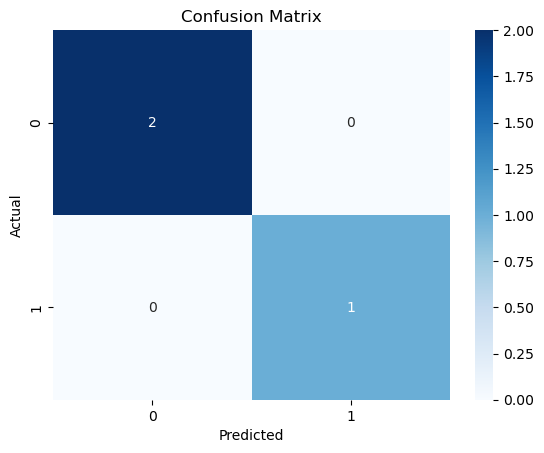

In [11]:
# 11. Confusion Matrix
cm = confusion_matrix(y_test,y_pred)
plt.figure()
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()